In [53]:
import pandas as pd
import sys
import importlib

In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
sys.path.append("../src")
import eda_utils as eda
import visualization as visual
import data_splitting as split
import preprocessing as prep

importlib.reload(eda)
importlib.reload(visual)
importlib.reload(prep)

<module 'preprocessing' from '/Users/isacassanello/Desktop/tercero/aprendizaje automatico y profundo/TP_Final_ML/notebooks/../src/preprocessing.py'>

In [56]:
dataset = pd.read_csv("../data/pf_suvs.csv")

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Exploratory Data Analysis
</h1>

In [57]:
# Columns Visualization
for column in dataset.columns:
    print(column)

Unnamed: 0
Marca
Modelo
Año
Versión
Color
Tipo de combustible
Puertas
Transmisión
Motor
Tipo de carrocería
Con cámara de retroceso
Kilómetros
Título
Precio
Moneda
Descripción
Tipo de vendedor


In [58]:
# Shape of the dataset
print(f"Cantidad de filas: {dataset.shape[0]}")
print(f"Cantidad de columnas: {dataset.shape[1]}")

Cantidad de filas: 18254
Cantidad de columnas: 18


In [59]:
TARGET = "Precio"

X = dataset.drop(columns = [TARGET])
y = dataset[TARGET]

In [60]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Label Analysis
</h3>

In [61]:
target_summary = eda.explore_target(y, currency = X["Moneda"])
display(target_summary)

,group,count,missing,missing_%,min,q1,median,mean,q3,max,std,zero_count
0,All,18254,0,0.0,111.0,31900.0,17200000.0,1.760162e+07,29950000.0,349500000.0,1.720810e+07,0
1,$,11158,0,0.0,119000.0,19000000.0,27320000.0,2.877461e+07,35900000.0,349500000.0,1.277861e+07,0
2,US$,7096,0,0.0,111.0,16000.0,24000.0,3.281019e+04,38900.0,610000.0,2.885445e+04,0


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Feature Analysis
</h3>

In [62]:
# Explore Dataset Features
feature_summary = eda.explore_features(X)

display(feature_summary["numeric"])
display(feature_summary["categorical"])

,feature,dtype,non_missing,missing,missing_%,min,max,mean,median,std,q1,q3,zero_count,outlier_count,outlier_%,unique,unique_%
0,Año,float64,18254,0,0.0,1981.0,436694.0,2042.796209,2019.0,3217.260996,2016.0,2024.0,0,260,1.42,40,0.22
1,Puertas,float64,18254,0,0.0,2.0,60252.0,18.167306,5.0,891.766121,5.0,5.0,0,523,2.87,7,0.04


,feature,dtype,categories_preview,most_frequent,most_frequent_count,most_frequent_%,least_frequent_preview,rare_categories,missing,missing_%,non_missing,unique,unique_%
0,Marca,object,Ford: 2161 | Jeep: 2050 | Volkswagen: 2037 | Chevrolet: 1750 | Renault: 1491,Ford,2161,11.84,Range Rover: 1 | Rrenault: 1 | Jetur: 1 | hiunday: 1 | Vol: 1,5,0,0.00,18254,47,0.26
1,Modelo,object,Ecosport: 1569 | Tracker: 1511 | 2008: 1144 | Duster: 1048 | Compass: 916,Ecosport,1569,8.60,Nativa: 2 | Defender: 2 | 208: 2 | C4 Aircross: 2 | F-PACE: 2,0,0,0.00,18254,137,0.75
2,Versión,object,1.6 Exclusive Cvt: 320 | 1.4 250 Tsi Comfortline: 261 | 1.4 250 Tsi Highline: 255 | 1.8 Ltz+ Awd At 140cv: 213 | 1.2...,1.6 Exclusive Cvt,320,1.75,1.6 Exclusive: 1 | TITANIUM 2.0L AT POWE: 1 | SV V8: 1 | 1.6 Gl Plus Allgrip 120cv: 1 | Trendline 200 Tsi Automatica...,1038,0,0.00,18254,2072,11.35
3,Color,object,Gris: 5468 | Blanco: 4809 | Negro: 2825 | Plateado: 1427 | Azul: 1121,Gris,5468,29.96,GRAY: 1 | Blanco Glaciar: 1 | GRIS ARTENSE: 1 | Cobre: 1 | ROJO SUNSET METALIZADO: 1,32,389,2.13,17865,70,0.38
4,Tipo de combustible,object,Nafta: 16067 | Diésel: 1328 | Nafta/GNC: 451 | Híbrido/Nafta: 269 | Híbrido: 105,Nafta,16067,88.02,Mild Hybrid: 10 | GNC: 12 | Eléctrico: 12 | Híbrido: 105 | Híbrido/Nafta: 269,0,0,0.00,18254,8,0.04
5,Transmisión,object,Automática: 12281 | Manual: 5834 | Automática secuencial: 123 | Semiautomática: 1,Automática,12281,67.28,Semiautomática: 1 | Automática secuencial: 123 | Manual: 5834 | Automática: 12281,1,15,0.08,18239,4,0.02
6,Motor,object,1.6: 4132 | 2.0: 3121 | 1.8: 1749 | 1.0: 1417 | 1.3: 1079,1.6,4132,22.64,45 TFSI 2.0 245cv: 1 | 1.3 Turbo AT9: 1 | 1.6 16 v: 1 | v8 4.4: 1 | 2.5 Híbrido: 1,159,38,0.21,18216,271,1.48
7,Tipo de carrocería,object,SUV: 18254,SUV,18254,100.00,SUV: 18254,0,0,0.00,18254,1,0.01
8,Con cámara de retroceso,object,Sí: 3731 | No: 960,Sí,3731,20.44,No: 960 | Sí: 3731,0,13563,74.30,4691,2,0.01
9,Kilómetros,object,0.0: 4237 | 0 km: 324 | 1000.0: 220 | 120000.0: 194 | 90000.0: 194,0.0,4237,23.21,43242.0: 1 | 168500.0: 1 | 60215.0: 1 | 71305.0: 1 | 29350.0: 1,1362,0,0.00,18254,2175,11.92


In [63]:
eda.duplicate_rows_summary(dataset)

,total_rows,duplicate_rows
0,18254,0


In [64]:
eda.missing_values_summary(dataset)

,column,missing_count,missing_percentage
0,Con cámara de retroceso,13563,74.30
1,Color,389,2.13
2,Motor,38,0.21
3,Transmisión,15,0.08


In [65]:
eda.unique_values_summary(dataset)

,column,unique_values,unique_pct
0,Unnamed: 0,18254,100.00
16,Descripción,12142,66.52
14,Precio,2914,15.96
13,Título,2220,12.16
12,Kilómetros,2175,11.92
4,Versión,2072,11.35
9,Motor,271,1.48
2,Modelo,137,0.75
5,Color,70,0.38
1,Marca,47,0.26


In [66]:
categorical_columns = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de combustible",
    "Transmisión",
    "Tipo de vendedor",
]

semantic_repetitions = eda.find_semantic_repetitions(dataset, columns = categorical_columns, similarity_threshold=0.80)

semantic_repetitions

,feature,similar_values,normalized_values,total_count,n_values_grouped
0,Color,Blanco | Blanca | BLANCA | blanca,blanca | blanco,4818,4
1,Color,Negro | Negra | NEGRA,negra | negro,2830,3
2,Color,Dorado | MORADO,dorado | morado,191,2
3,Color,Amarillo | Amarrillo,amarillo | amarrillo,25,2
4,Color,Plata | PLATA,plata,9,2
5,Color,Gris plata | GRIS PLATA | GRIS PLATINO,gris plata | gris platino,5,3
6,Color,Marrón oscuro | Marrón claro,marron claro | marron oscuro,3,2
7,Color,BLANCO GLACIAR | Blanco Glaciar,blanco glaciar,2,2
8,Color,GRANITE CRYSTA BC | GRANITE CRYSTAL BC,granite crysta bc | granite crystal bc,2,2
9,Marca,Renault | Rrenault,renault | rrenault,1492,2


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Initial Graphics Analysis
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Data Quality
</div>

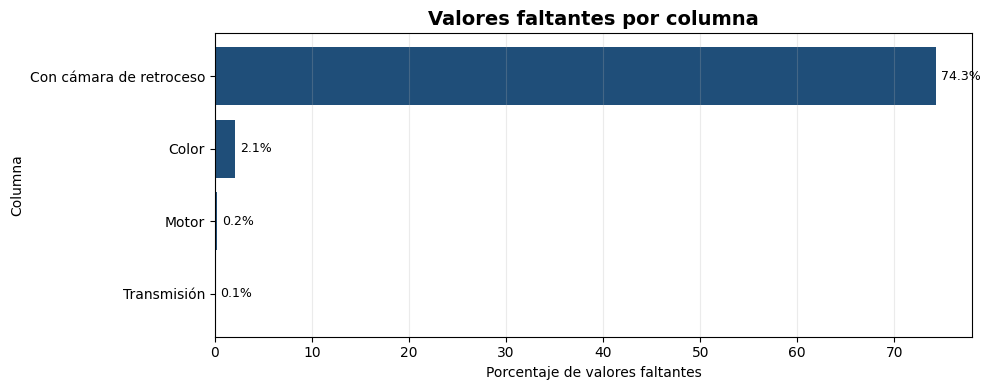

In [67]:
visual.plot_missing_values(dataset)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Categorical Variables
</div>

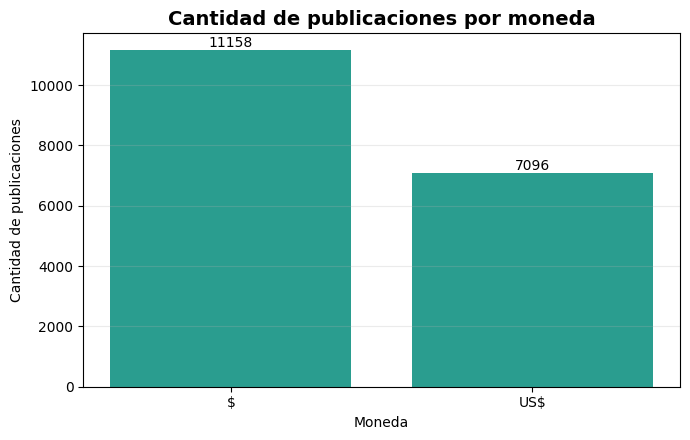

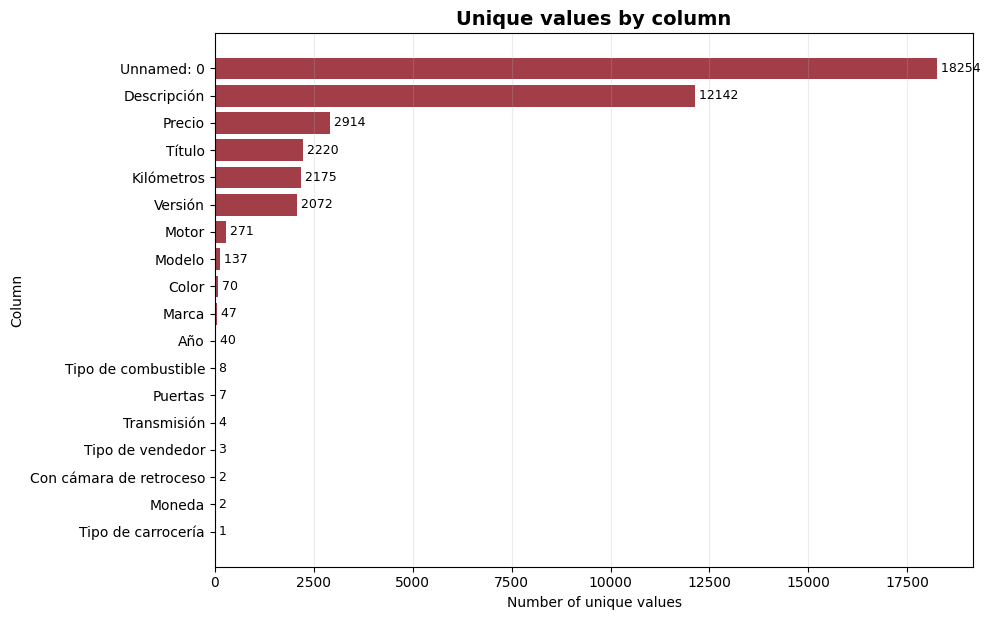

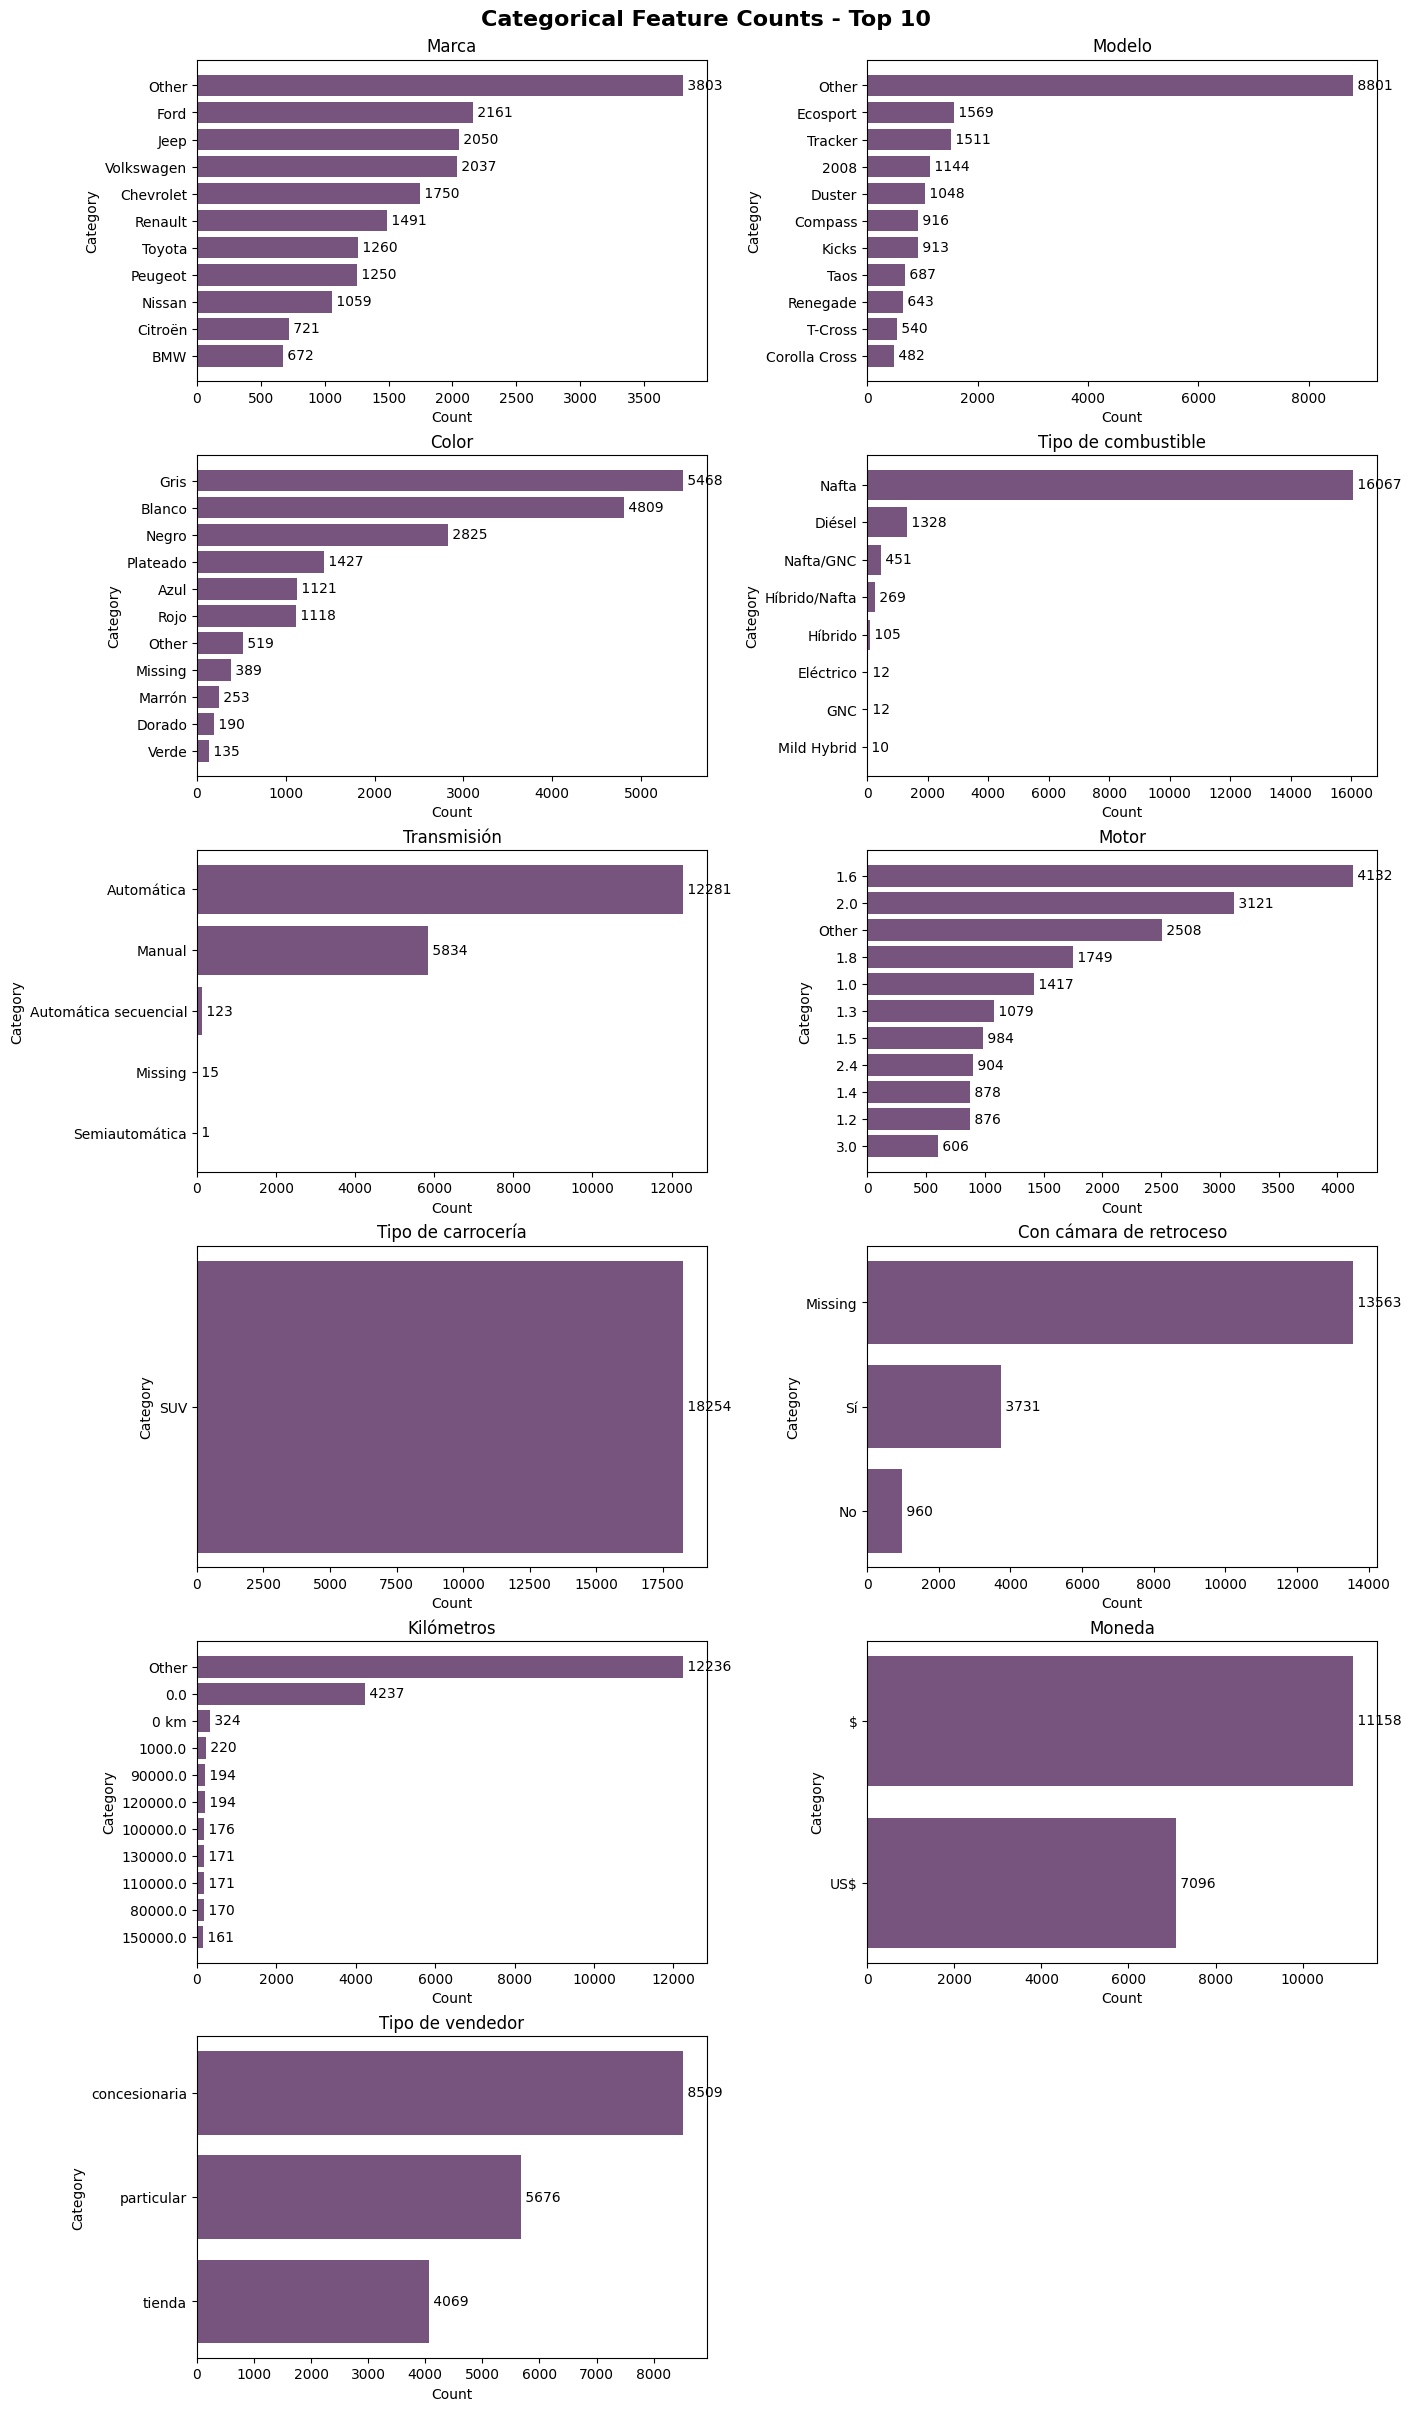

In [68]:
visual.plot_currency_counts(dataset)
visual.plot_unique_values(dataset)
visual.plot_categorical_counts(X, ignored_columns=["Título", "Descripción", "Versión"], top_n = 10, n_cols = 2)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Numerical Variables
</div>

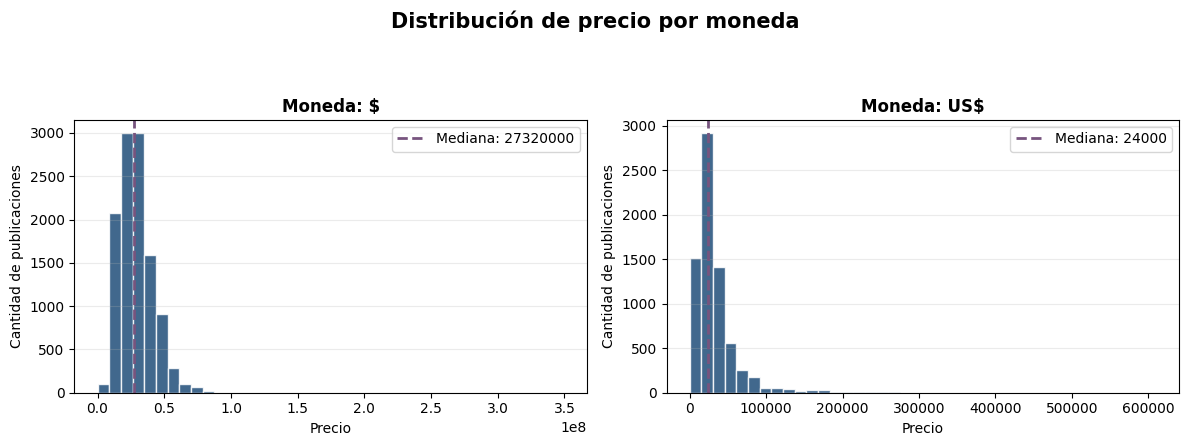

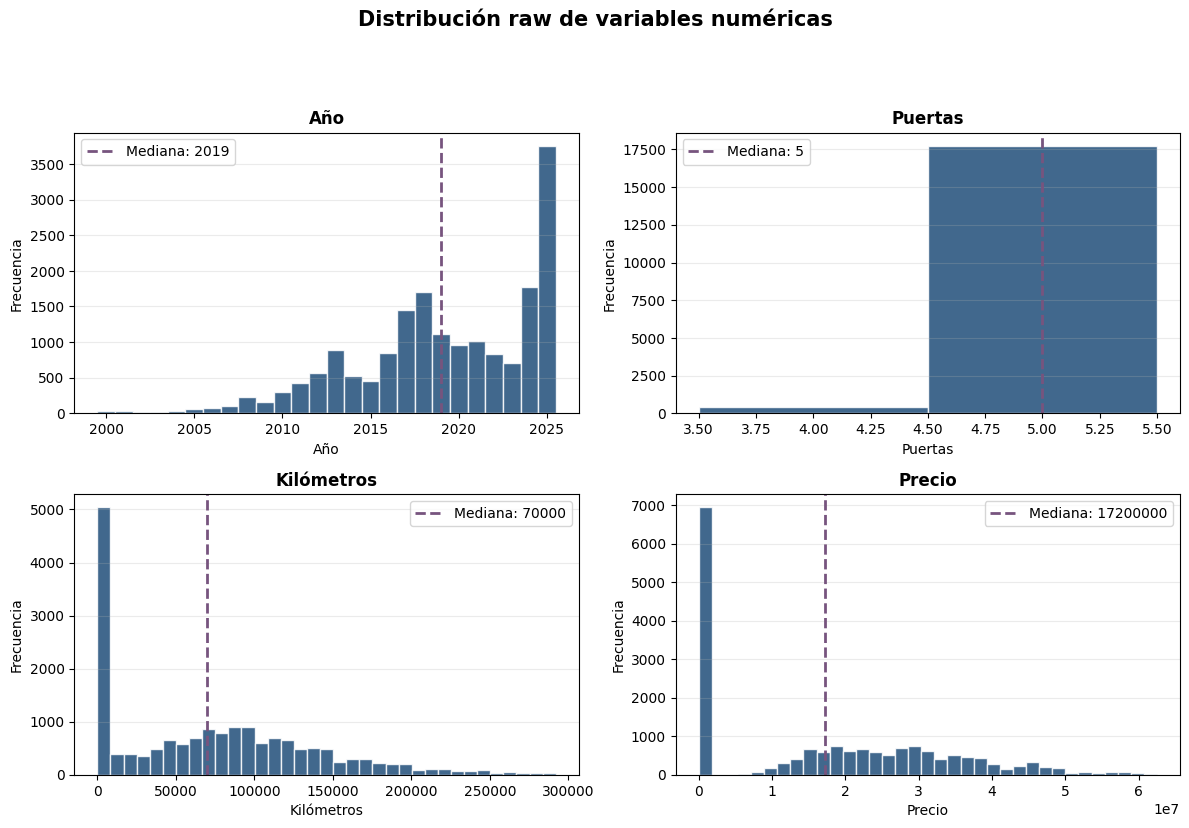

In [69]:
visual.plot_price_distribution_by_currency(dataset)
visual.plot_raw_numeric_distributions(dataset)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Preliminary Outlier Detection
</div>

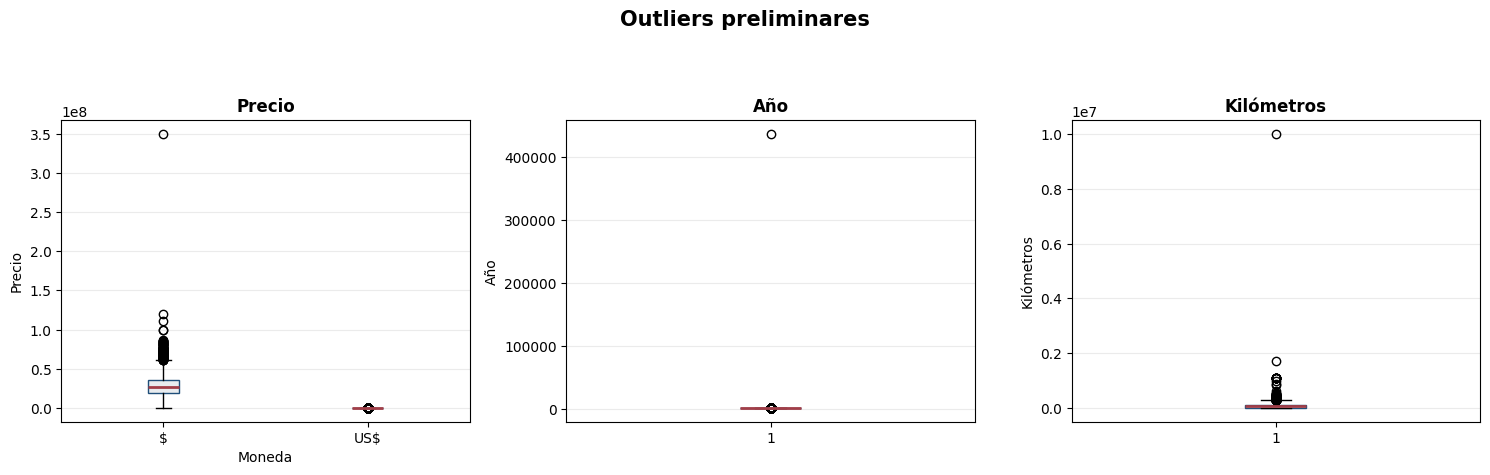

In [70]:
visual.plot_preliminary_outliers(dataset)

En las distribuciones raw se observan algunos valores claramente atípicos que afectan la forma de los gráficos. Por ejemplo, en `Año` aparece un valor imposible y en `Puertas` hay registros con cantidades extremadamente altas. Estos valores hacen que el eje del histograma se estire mucho y que la mayor parte de las observaciones reales quede comprimida en una sola zona.

Por eso, para visualizar mejor las distribuciones, se filtraron los valores extremos solo al momento de graficar, usando percentiles. Esto no implica eliminar datos todavía, sino simplemente evitar que unos pocos outliers deformen el gráfico. La limpieza o corrección definitiva de estos valores se realizará más adelante durante el preprocesamiento.

Con este chequeo se detectan valores incoherentes en dos variables. En `Año` aparece una observación con valor `436694`, claramente mayor al año actual, por lo que se trata de un error de carga. Además, en `Puertas` se observa un valor máximo de `60252`, con 4 observaciones que tienen más de 7 puertas, lo cual tampoco es razonable para este tipo de vehículos.

Como estos casos son pocos y corresponden a valores no interpretables, se podrian eliminar directamente en el preprocesamiento

<h3
style="background-color: #343a40; color: #ffffff; 
display: inline-block; 
padding: 6px 10px;
border-radius: 6px;">
Initial Preprocessing
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Drop irrelevant columns
</div>

En primer lugar, se eliminan aquellas columnas que no aportan información útil para el entrenamiento de los modelos predictivos.

Por un lado, la columna **`Unnamed: 0`** corresponde al índice del dataset exportado a CSV y no contiene información descriptiva sobre los vehículos.

In [71]:
dataset_processed = prep.drop_irrelevant_columns(dataset.copy(), columns_to_drop=["Unnamed: 0"])

Por otro lado, se verifica si existen variables constantes, es decir, columnas cuyos valores son iguales para todas las observaciones. Este tipo de variables no aportan capacidad predictiva, ya que no permiten diferenciar entre ejemplos

In [72]:
constant_columns = eda.get_constant_columns(dataset_processed)
constant_columns

,column,unique_value
0,Tipo de carrocería,SUV


Se observa que la única variable constante del conjunto de datos es **`Tipo de carrocería`**, cuyo valor es **"SUV"** para todas las publicaciones.

Dado que el dataset está compuesto exclusivamente por vehículos SUV, esta variable no aporta información discriminativa y, por lo tanto, se elimina del conjunto de datos.

In [73]:
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Tipo de carrocería"])

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Remove inconsistent values
</div>

In [74]:
print("=== Chequeo de valores atípicos simples ===")
print(f"Año máximo: {dataset['Año'].max()}")
print(f"Cantidad de años mayores a 2025: {(dataset['Año'] > 2025).sum()}")
print()
print(f"Cantidad máxima de puertas: {dataset['Puertas'].max()}")
print(f"Cantidad de observaciones con más de 5 puertas: {(dataset['Puertas'] > 5).sum()}")

=== Chequeo de valores atípicos simples ===
Año máximo: 436694.0
Cantidad de años mayores a 2025: 1

Cantidad máxima de puertas: 60252.0
Cantidad de observaciones con más de 5 puertas: 9


El chequeo muestra que existe una observación con un valor de **`Año`** igual a **436694**, lo cual no es interpretable como año de fabricación del vehículo.

Además, la variable **`Puertas`** presenta un valor máximo de **60252**, y se detectan observaciones con más de 5 puertas. Dado que estos valores no son razonables para vehículos SUV, se consideran inconsistencias del dataset y se eliminan antes del entrenamiento de los modelos.

In [75]:
range_rules = {
    "Año": {"max": 2025},
    "Puertas": {"max": 5},
}

dataset_processed = prep.remove_invalid_values(dataset_processed, range_rules)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Convert prices to USD
</div>

Para entrenar un modelo predictivo consistente, todos los precios deben estar expresados en una misma moneda. Dado que el dataset contiene publicaciones en pesos argentinos y en dólares estadounidenses, se convierten los precios publicados en pesos a USD.

El dataset fue construido entre el 13/05/2025 y el 30/05/2025. Por este motivo, se utiliza como tipo de cambio el promedio de la cotización diaria del dólar oficial vendedor del Banco Nación durante ese período.

In [76]:
official_usd_sell = {
    "2025-05-13": 1150.00,
    "2025-05-14": 1150.00,
    "2025-05-15": 1150.00,
    "2025-05-16": 1160.00,
    "2025-05-19": 1155.00,
    "2025-05-20": 1160.00,
    "2025-05-21": 1160.00,
    "2025-05-22": 1155.00,
    "2025-05-23": 1150.00,
    "2025-05-26": 1160.00,
    "2025-05-27": 1170.00,
    "2025-05-28": 1175.00,
    "2025-05-29": 1195.00,
    "2025-05-30": 1195.00,
}

In [77]:
EXCHANGE_RATE = sum(official_usd_sell.values()) / len(official_usd_sell)
print(f"El tipo de cambio utilizado es de ${EXCHANGE_RATE:.2f}")

El tipo de cambio utilizado es de $1163.21


In [78]:
dataset_processed = prep.convert_peso_prices_to_usd(dataset_processed, exchange_rate = EXCHANGE_RATE)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Kilometers to int
</div>

Como se observó, la columna `Kilómetros` es un string, por lo que hay que convertirla a float, teniendo en cuenta que algunos, valores incluyen la unidad "km", la cual será eliminada

In [79]:
dataset_processed["Kilómetros"] = (
    dataset_processed["Kilómetros"]
    .apply(prep.extract_first_integer)
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Semantic Cleaning of Categorical Features
</div>

En esta sección se limpian y unifican categorías que representan el mismo valor pero aparecen escritas de distintas formas. Esto incluye diferencias de mayúsculas, tildes, guiones, espacios o variantes semánticamente equivalentes, como `Blanco`, `blanco` y `Blanca`.

Antes de aplicar los cambios, se revisaron las categorías disponibles y se exploraron posibles repeticiones semánticas en variables como `Color`, `Marca`, `Modelo`, `Tipo de combustible`, `Transmisión` y `Motor`. Este análisis permitió decidir qué columnas podían limpiarse con un mapeo manual y cuáles requerían más cuidado para no unir categorías que en realidad representan valores distintos.

Para aplicar los reemplazos se utiliza una función de mapeo semántico. Primero, cada valor se normaliza con `normalize_category_text`, que transforma el texto a minúsculas, elimina tildes, reemplaza guiones y espacios inconsistentes, y deja las categorías en un formato comparable. Luego, `apply_semantic_mapping` usa los mapas definidos manualmente para reemplazar cada variante por una categoría final estandarizada.

Los valores faltantes también se normalizan como la categoría explícita `missing`. Esta decisión permite conservar la información de ausencia como una categoría propia, en lugar de perderla durante el one-hot encoding. En algunas variables, como `Color` o `Transmisión`, que un dato esté faltante puede aportar información sobre la publicación o el tipo de vehículo, por lo que se mantiene como señal disponible para el modelo.

Después de esta limpieza, las columnas categóricas quedan con valores más consistentes y listas para las siguientes etapas de imputación, análisis y codificación.

In [80]:
BRAND_MAP = {
    "renault": ["renault", "rrenault"],
    "hyundai": ["hiunday", "hyundai"],
    "volkswagen": ["volkswagen", "vol"],
    "ds": ["ds", "d.s.", "d·s", "ds automobiles"],
    "land rover": ["range rover", "land rover"],
    "great wall motor": ["gwm", "haval"],
    "volkswagen": ["volkswagen", "vol"],
    "otros": ["alfa romeo", "jac", "jetour", "jetur", "isuzu", "lifan", "lexus", 
              "subaru", "daihatsu", "mini", "kaiyi", "jaguar",],
}

MODEL_MAP = {
    "sw4": ["sw4", "hilux sw4"],
    "ds7": ["ds7", "ds7 crossback"],
    "clase ml": ["clase ml", "ml"],
    "santa fe": ["santa fe", "grand santa fe", "grand santa fé"],
    "tiggo 4": ["tiggo 4", "tiggo 4 pro"],
}

COLOR_MAP = {
    "blanco": ["blanca", "blanco", "blanco glaciar", "summit white", "mineralweiss metallic", "blanco nacre tricapa", "blanco banquise"],
    "negro": ["negra", "negro", "carbon black", "black meet kettle", "noir perla nera"],
    "amarillo": ["amarilla", "amarillo", "amarrillo"],
    "dorado": ["dorada", "dorado", "champaing"],
    "gris": ["gris", "gris plata", "gris platino", "plata", "plateado", "gray", "gris laque", "plata bari", "prata bari+tet vulc", "gris estrella", "gris artense"],
    "gris oscuro": ["gris oscuro", "gris selenium", "grafito", "granite crystal bc", "granite crysta bc", "gris titane", "gris indy", "gris silverstone", "skyscraper grau metallic"],
    "marron": ["marron claro", "marron oscuro", "cafe", "marron kodiak"],
    "azul": ["azul", "steel blue", "blue"],
    "rojo": ["rojo", "rojo sunset metalizado"],
    "verde": ["verde", "verde oscuro"],
    "beige": ["beige", "beige techo negro"],
    "celeste": ["celeste", "azul claro"],
    "naranja": ["naranja", "cobre"],
    "violeta": ["violeta", "morado", "morado oscuro"],
    "bordo": ["bordo"],
    "otros": ["otro", "acero", "rosa", "moundaz", "cendre", "blanco banchisa bicolor negro"]
}

FUEL_TYPE_MAP = {
    "hibrido ": ["hibrido", "hibrido/nafta"]
}

TRANSMISSION_MAP = {
    "automatica ": ["automática", "automatica", "automatica secuencial", "automática secuencial", "semiautomatica", "semiautomática"]
}


In [81]:
dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Marca", 
                                               category_map = BRAND_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Modelo", 
                                               category_map = MODEL_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Color", 
                                               category_map = COLOR_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Tipo de combustible", 
                                               category_map = FUEL_TYPE_MAP)

dataset_processed = prep.apply_semantic_mapping(dataset_processed, column = "Transmisión", 
                                               category_map = TRANSMISSION_MAP)

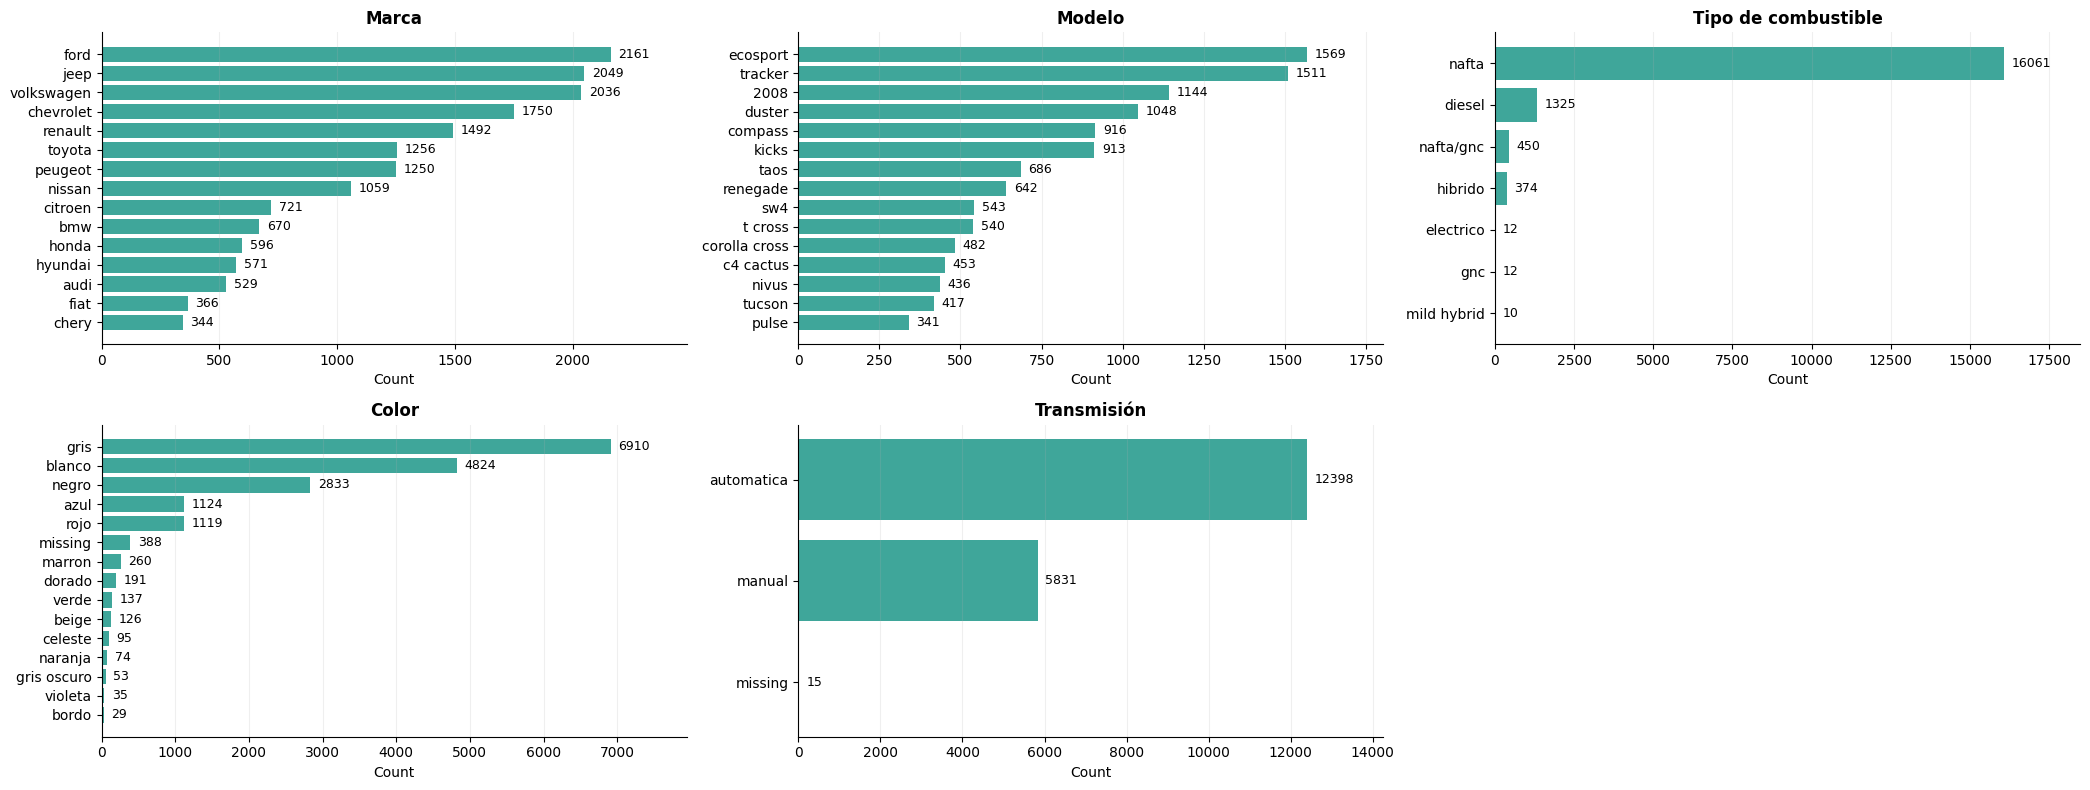

In [82]:
categorical_columns_to_check = [
    "Marca",
    "Modelo",
    "Tipo de combustible",
    "Color",
    "Transmisión",
]

visual.plot_compact_value_counts(
    dataset_processed,
    columns=categorical_columns_to_check,
    top_n=15,
    n_cols=3
)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Encode binary features
</div>

Algunas variables categóricas representan información binaria, es decir, valores de tipo **sí/no**. Para que puedan ser utilizadas por los modelos predictivos, estas variables deben transformarse a una representación numérica.

En este caso, la variable **`Con cámara de retroceso`** se codifica como:

- **1** si el vehículo tiene cámara de retroceso
- **0** si el vehículo no tiene cámara de retroceso

In [83]:
camera_map = {
    "sí": 1,
    "si": 1,
    "no": 0,
}

dataset_processed = prep.map_column_values(dataset_processed, column = "Con cámara de retroceso", value_map = camera_map)

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Missing Value Handling
</div>

### Color

In [84]:
color_summary, color_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Color",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=COLOR_MAP,
)

# Only rows where color is missing but is mentioned
color_row_mentions[
    (color_row_mentions["Color_is_missing"])
    & (color_row_mentions["n_category_mentions"] > 0)
]

,row_index,Color_is_missing,matched_categories,n_category_mentions
4405,4407,True,azul,1
4474,4476,True,blanco | negro,2
6774,6776,True,gris,1
8798,8804,True,beige,1
10782,10789,True,blanco | negro,2
10877,10884,True,azul,1
11088,11095,True,blanco | gris | gris oscuro | negro,4
11453,11460,True,blanco | negro,2
13129,13138,True,negro,1
13211,13220,True,gris | negro,4


A partir de la búsqueda de colores en las columnas de texto (`Título`, `Descripción` y `Versión`), se observa que algunas publicaciones con `Color` faltante sí contienen información recuperable en su descripción textual.

En estos casos, el valor de `Color` aparece mencionado explícitamente en el texto y, luego de aplicar la misma normalización semántica utilizada para limpiar categorías, puede identificarse una categoría de color válida. Esto permite recuperar parte de los valores faltantes sin recurrir a una imputación estadística general.

Sin embargo, no todos los casos son igual de confiables. Cuando se detecta una única categoría en el texto, por ejemplo `azul`, `gris`, `beige`, `negro` o `blanco`, la imputación parece razonable. En cambio, cuando aparecen múltiples colores en una misma publicación, como `blanco | negro` o `blanco | gris | gris oscuro | negro`, el valor puede referirse a detalles, interiores, combinaciones bitono o accesorios, por lo que imputar automáticamente sería más riesgoso.

Por este motivo, se decide utilizar esta información de forma conservadora: imputar `Color` únicamente cuando la publicación tiene el valor faltante y el texto contiene una sola categoría de color detectada. Los casos con múltiples colores mencionados se mantienen como faltantes o como categoría `missing`, ya que no hay suficiente certeza para asignar un único color principal.

In [85]:
dataset_processed, color_fill_audit = prep.fill_missing_from_single_text_match(
    dataset_processed,
    target_col="Color",
    matches_df = color_row_mentions,
)

color_fill_audit

Missing rows in 'Color' before filling: 388
Rows filled from text matches: 8
Missing rows in 'Color' after filling: 380


,row_index,matched_categories,n_unique_matches,fill_value,target_col
4405,4407,azul,1,azul,Color
6774,6776,gris,1,gris,Color
8798,8804,beige,1,beige,Color
10877,10884,azul,1,azul,Color
13129,13138,negro,1,negro,Color
14795,14804,blanco,1,blanco,Color
15334,15343,gris,1,gris,Color
16474,16483,blanco,1,blanco,Color


### Motor
Imprimimos todas las muestras en donde hayan valores faltantes en la columna `Motor`

In [86]:
ENGINE_TEXT_MAP = {
    "1.0": [
        "1.0",
        "1.0t",
        "1.0 t",
        "1.0 tsi",
        "1.0 200 tsi",
    ],
    "1.3": [
        "1.3",
        "1.3 tce",
        "1.3 tce turbo",
        "1.3 t270",
    ],
    "1.5": [
        "1.5",
        "1.5t",
        "1.5 t",
        "1.5 turbo",
    ],
    "1.6": [
        "1.6",
        "1.6l",
        "1.6 16v",
        "1.6 vti",
        "1.6 thp",
    ],
    "1.8": [
        "1.8",
    ],
    "2.0": [
        "2.0",
        "2.0 sport",
        "2.0 sel",
        "2.0 hse",
        "2.0 turbo",
        "2.0 turbonaftero",
    ],
    "2.5": [
        "2.5",
    ],
    "2.8": [
        "2.8",
    ],
}

In [87]:
engine_summary, engine_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col="Motor",
    text_cols=("Título", "Descripción", "Versión"),
    category_map = ENGINE_TEXT_MAP,
)

engine_row_mentions[
    (engine_row_mentions["Motor_is_missing"])
    & (engine_row_mentions["n_category_mentions"] > 0)
]

,row_index,Motor_is_missing,matched_categories,n_category_mentions
209,209,True,2.5,2
219,219,True,1.0,4
2486,2488,True,1.6,2
2762,2764,True,1.8,3
3622,3624,True,1.5,6
3758,3760,True,1.6,4
4416,4418,True,1.6,4
6093,6095,True,1.5,3
7909,7915,True,1.5,2
8258,8264,True,1.0,2


In [88]:
dataset_processed, engine_audit = prep.fill_missing_from_text(
    dataset_processed,
    target_col="Motor",
    text_cols=("Versión", "Título", "Descripción"),
    extractor=prep.extract_engine_liters_from_text,
    extracted_col_name="extracted_liters",
)

engine_audit[engine_audit["was_filled"]].head(10)

Missing rows in 'Motor': 38
Filled from text: 21
Still missing after text search: 17


,row_index,text_used,extracted_liters,was_missing,was_filled
0,209,4X2 Hibrida AT Ford Kuga 2.5 Hibrida 4x2 At 2020 Ford Kuga 2.5 Hibrida 4X2 At 2020 con 45000 km. Oportunidad!!Unida...,2.5,True,True
1,219,1.0 200 Tsi Highline Tip Volkswagen T-Cross 1.0 200 Tsi Highline Tip Descubrí nuestro impresionante Volkswagen T-Cr...,1.0,True,True
7,2488,"1.6 S 110cv 4x2 Ford Ecosport 1.6 S 110cv 4x2 Descubre nuestro impresionante Ford Eco Sport del año 2017, en color ...",1.6,True,True
8,2764,1.8 4x2 Sport Jeep Renegade 1.8 4x2 Sport Somos ExpoUsados de San Luis Jeep Renegade 1.8 4X2 Sport 2018 con 62297 k...,1.8,True,True
9,3624,"1.5 Turbo LX 4x2 Honda Cr-v 1.5 Turbo Lx 4x2 Honda CRV LX 4X2 1.5 turbo 191cv, Blanco perlado, entrega inmdata",1.5,True,True
10,3760,1.6 Thp 165 At6 Shine Citroën C4 Cactus 1.6 Thp 165 At6 Shine Descubrí nuestro impresionante Citroen C 4 Cactus del...,1.6,True,True
13,4418,"1.6 Vti 115 X-series Citroën C4 Cactus 1.6 Vti 115 X-series * ¡TU AUTO USADO, PARA RPM VALE MAS!Pagamos más por tu ...",1.6,True,True
15,6095,1.5t Titanium Ford Territory 1.5t Titanium Usados | dietrich • Marca: Ford• Modelo: Territory Titanium 1.5t Cvt• Añ...,1.5,True,True
19,7915,"1.5t Titanium Ford Territory 1.5t Titanium Descubre nuestro impresionante Ford Territory del año 2022, en color Bla...",1.5,True,True
20,8264,1.0T Gt Peugeot 2008 1.0t Gt El vendedor no incluyó una descripción del producto,1.0,True,True


### Transmisión

In [89]:
TRANSMISSION_MAP_TEXT = {
    "automatica": [
        "automatica",
        "automatico",
        "caja automatica",
        "at",
        "at6",
        "at8",
        "at9",
        "cvt",
        "dsg",
        "tiptronic",
        "secuencial",
    ],
    "manual": [
        "manual",
        "caja manual",
        "mt",
    ],
}

In [90]:
transmission_summary, transmission_row_mentions = eda.count_category_mentions_in_text(
    dataset_processed,
    target_col = "Transmisión",
    text_cols=("Título", "Descripción", "Versión"),
    category_map=TRANSMISSION_MAP_TEXT,
)

# Only rows where transmission is missing but is mentioned
transmission_row_mentions[
    (transmission_row_mentions["Transmisión_is_missing"])
    & (transmission_row_mentions["n_category_mentions"] > 0)
]

,row_index,Transmisión_is_missing,matched_categories,n_category_mentions
2192,2194,True,automatica,2
5505,5507,True,automatica,2
7658,7663,True,automatica,4
12911,12920,True,automatica,2
12970,12979,True,automatica,2
17584,17594,True,automatica,4
17655,17665,True,automatica | manual,8


In [91]:
dataset_processed, transmission_fill_audit = prep.fill_missing_from_single_text_match(
    dataset_processed,
    target_col="Transmisión",
    matches_df=transmission_row_mentions,
)
transmission_fill_audit

Missing rows in 'Transmisión' before filling: 15
Rows filled from text matches: 6
Missing rows in 'Transmisión' after filling: 9


,row_index,matched_categories,n_unique_matches,fill_value,target_col
2192,2194,automatica,1,automatica,Transmisión
5505,5507,automatica,1,automatica,Transmisión
7658,7663,automatica,1,automatica,Transmisión
12911,12920,automatica,1,automatica,Transmisión
12970,12979,automatica,1,automatica,Transmisión
17584,17594,automatica,1,automatica,Transmisión


### Con cámara de retroceso
Imprimimos todas las muestras en donde hayan valores faltantes en la columna Con cámara de retroceso

In [92]:
dataset_processed, camera_audit = prep.fill_missing_from_text(
    dataset_processed,
    target_col="Con cámara de retroceso",
    text_cols=("Título", "Descripción", "Versión"),
    extractor=prep.extract_backup_camera,
    extracted_col_name="extracted_camera",
)

camera_audit[camera_audit["was_filled"]].head(10)

Missing rows in 'Con cámara de retroceso': 13556
Filled from text: 486
Still missing after text search: 13070


,row_index,text_used,extracted_camera,was_missing,was_filled
2,4,Jeep Compass 2.4 Sport At •Unico dueño•Todos los services oficiales•Bateria nueva•2 juegos de alfombras•Caja Automa...,1.0,True,True
22,36,Mercedes-Benz Clase GLE GLE 450 4MATIC (MHEV) Desde AutoPremium Usados Seleccionados tenemos para ofrecerte una MER...,1.0,True,True
27,45,"Kia Sorento 2.5 Ex Crdi 170 Hp At Kia sorento motor 2.5 de 170 hp estéreo sistema Android, bluetooth, gps,cámara de...",1.0,True,True
33,54,Toyota RAV4 2.5 4x4 6at TOYOTA RAV4 VX 2.5l 4x4 AT - modelo 2013- segundo dueño 136.000km- motor 2.5l (cadenero)- t...,1.0,True,True
58,86,BMW X3 2.0 Xdrive 30E Xline Descripción!!!!Desde AutoPremium Usados Seleccionados tenemos para ofrecerte un BMW X3 ...,1.0,True,True
111,155,Audi Q3 1.4 Tfsi Stronic 150 Cv Audi Q3 35 TFSI35 TFSI corresponde a motor 1.4 TFSI de 150CV- Audi drive select- Au...,1.0,True,True
124,175,"Chery Tiggo 2.0 F2 Confort 4x2 138cv Chery Tiggo 2014, con GNC,luces led y estero Pionner, se entrega con la camara...",1.0,True,True
155,225,"Toyota Corolla Cross 2.0 Seg Cvt Toyota Corolla Cross 2025 - 21 km, retirado de agencia y guardado en garage, la má...",1.0,True,True
159,230,Chevrolet Equinox 1.5t Premier 4wd CHEVROLET EQUINOX 1.5T PREMIER AWD AT 2019 / 58.582 KM / EXCELENTE ESTADO con CU...,1.0,True,True
186,269,Jeep Commander 1.3 T270 Limited 4X2 At6 ANTICIPO + CUOTASFINANCIACIÓN PRE CANCELABLELlantas de aleación 18”.Sist. m...,1.0,True,True


### Checking updated dataset

In [93]:
# previous missing values
eda.missing_values_summary(dataset)

,column,missing_count,missing_percentage
0,Con cámara de retroceso,13563,74.30
1,Color,389,2.13
2,Motor,38,0.21
3,Transmisión,15,0.08


In [94]:
eda.missing_values_summary(dataset_processed)

,column,missing_count,missing_percentage
0,Con cámara de retroceso,13070,71.64
1,Color,380,2.08
2,Motor,17,0.09
3,Transmisión,9,0.05


<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
New Columns to Represent Engine Feature
</div>

Para la variable `Motor`, se busca extraer información técnica que aparece escrita de distintas formas en el texto original. En particular, se recupera la cilindrada del motor y se conserva la presencia de turbo cuando esta información aparece explícitamente mencionada.

Ya se completaron algunos valores faltantes de `Motor` utilizando las columnas `Título`, `Descripción` y `Versión`. Para esto se identifican patrones confiables de cilindrada, como `1.6`, `2.0`, `1.5t`, `1.3 TCE`, `1.0 TSI` o valores en centímetros cúbicos como `1600 cc`. Cuando además se detectan expresiones asociadas a turbo, como `turbo`, `TSI`, `TDI`, `THP` o `TCE`, el valor imputado conservó esa información en el texto, por ejemplo `1.5 turbo`.

Luego, a partir de la columna `Motor` ya completada, se crean nuevas variables. La columna `Cilindrada` almacena la cilindrada extraída en litros como valor numérico, mientras que `Tiene turbo` indica si el motor presenta señales de turbo en el texto. Además, se genera `Grupo cilindrada`, una variable ordinal que resume la cilindrada en rangos ordenados para facilitar su uso posterior en análisis y modelado.

De esta forma, la información técnica contenida originalmente en `Motor` queda representada en columnas más limpias y comparables. Una vez creadas estas variables derivadas, la columna original `Motor` puede eliminarse del dataset final.

In [95]:
TURBO = [
    "turbo",
    "turboalimentado",
    "tsi",
    "tdi",
    "tfsi",
    "ecoboost",
    "tce",
    "thp",
    r"\bt\b", # Match 't' as a whole word
    r"\d\.\d\s*t\b", # Match patterns like '1.6 T'
]

In [96]:
dataset_processed["Cilindrada"] = dataset_processed["Motor"].apply(prep.extract_engine_liters)
dataset_processed["Cilindrada"].isna().sum()

np.int64(311)

Algunas columas de `Motor` solo decian cosas como "Turboalimentado", por lo que tienen NAN a la hora de completar la cilindrada. Esos valores los podemos recuperar de las columnas `Versión` y `Descripción`

In [97]:
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Versión"].apply(prep.extract_engine_liters)
dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Cilindrada"] = dataset_processed.loc[dataset_processed["Cilindrada"].isna(), "Descripción"].apply(prep.extract_engine_liters)

In [98]:
print(dataset_processed["Cilindrada"].isna().sum())
print(dataset_processed["Cilindrada"].head())

22
0    1.5
1    2.0
2    1.4
3    1.5
4    2.4
Name: Cilindrada, dtype: float64


In [99]:
dataset_processed["Grupo cilindrada"] = dataset_processed["Cilindrada"].apply(prep.encode_engine_size)
dataset_processed["Tiene turbo"] = dataset_processed["Motor"].apply(lambda value: prep.has_turbo(value, turbo_patterns = TURBO))

In [100]:
# Deleting Motor column as it has been processed into new features
dataset_processed = prep.drop_irrelevant_columns(dataset_processed, columns_to_drop = ["Motor"])

In [101]:
print(dataset_processed["Grupo cilindrada"].value_counts())
print(dataset_processed["Grupo cilindrada"].isna().sum())

Grupo cilindrada
2    7412
3    5057
1    2462
4    2061
5    1230
0      22
Name: count, dtype: int64
0


In [102]:
dataset_processed["Tiene turbo"].value_counts()

Tiene turbo
0    17879
1      365
Name: count, dtype: int64

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Data Splitting
</h3>

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Stratified by Brand
</div>

In [103]:
X_pp = dataset_processed.drop(columns = [TARGET])
y_pp = dataset_processed[TARGET]

In [104]:
train_set, val_set = split.train_val_split_stratified(X_pp, y_pp, stratify_by = X_pp["Marca"], train_size = 0.80)

X_train, y_train = train_set
X_val, y_val = val_set

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
One Hot Encoding
</h3>

In [105]:
categorical_cols_to_encode = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión"
]

X_train_encoded, categories_map = prep.one_hot_encoding(
    X_train,
    categorical_cols = categorical_cols_to_encode,
    train = True
)

X_val_encoded = prep.one_hot_encoding(
    X_val,
    categorical_cols = categorical_cols_to_encode,
    train = False,
    categories_map = categories_map
)

In [106]:
# Split check
display(split.split_size_summary(X_train, X_val))

,split,rows,percentage
0,train,14597,80.01
1,validation,3647,19.99


In [107]:
# X_train_encoded = X_train_encoded.copy()
# X_val_encoded = X_val_encoded.copy()

# X_train_encoded.to_csv("../data/pf_suvs_xtrain_encoded.csv", index = False)
# X_val_encoded.to_csv("../data/pf_suvs_xval_encoded.csv", index = False)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Checking preprocessed dataset
</h3>

In [108]:
fueture_pp_summary = eda.explore_features(X_train_encoded)
display(fueture_pp_summary["numeric"])

,feature,dtype,non_missing,missing,missing_%,min,max,mean,median,std,q1,q3,zero_count,outlier_count,outlier_%,unique,unique_%
0,Año,float64,14597,0,0.00,1981.0,2025.0,2018.982805,2019.0,5.539407,2016.0,2024.0,0,215,1.47,38,0.26
1,Puertas,float64,14597,0,0.00,2.0,5.0,4.964102,5.0,0.224431,5.0,5.0,0,418,2.86,4,0.03
2,Con cámara de retroceso,float64,4150,10447,71.57,0.0,1.0,0.816867,1.0,0.386822,1.0,1.0,760,760,5.21,2,0.01
3,Kilómetros,int64,14597,0,0.00,0.0,9999999.0,75018.338905,67245.0,112448.431514,0.0,116000.0,3659,154,1.06,1878,12.87
4,Cilindrada,float64,14581,16,0.11,1.0,8.0,1.820822,1.6,0.656478,1.5,2.0,0,1445,9.90,43,0.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Tipo de combustible_nafta,int64,14597,0,0.00,0.0,1.0,0.882716,1.0,0.321770,1.0,1.0,1712,1712,11.73,2,0.01
192,Tipo de combustible_nafta/gnc,int64,14597,0,0.00,0.0,1.0,0.023635,0.0,0.151914,0.0,0.0,14252,345,2.36,2,0.01
193,Transmisión_automatica,int64,14597,0,0.00,0.0,1.0,0.679866,1.0,0.466544,0.0,1.0,4673,0,0.00,2,0.01
194,Transmisión_manual,int64,14597,0,0.00,0.0,1.0,0.319586,0.0,0.466332,0.0,1.0,9932,0,0.00,2,0.01


In [109]:
display(eda.missing_values_summary(X_train_encoded))

,column,missing_count,missing_percentage
0,Con cámara de retroceso,10447,71.57
1,Cilindrada,16,0.11


In [110]:
display(eda.unique_values_summary(X_train_encoded))

,column,unique_values,unique_pct
6,Descripción,9962,68.25
5,Título,1952,13.37
4,Kilómetros,1878,12.87
1,Versión,1825,12.50
7,Cilindrada,43,0.29
...,...,...,...
72,Modelo_duster,2,0.01
73,Modelo_duster oroch,2,0.01
74,Modelo_ecosport,2,0.01
75,Modelo_equinox,2,0.01
